# Gen-PPL

Analyze Gen-PPL results.

In [1]:
import os
CUDA_VISIBLE_DEVICES=0
os.environ['CUDA_VISIBLE_DEVICES'] = f"{CUDA_VISIBLE_DEVICES}"
import torch


print(f"visible GPUs: {torch.cuda.device_count()}")

visible GPUs: 1


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

RESULTS_PATH = "outputs/qwen4Beval_2/all_metrics_analysis/divergence_metrics.csv"

df = pd.read_csv(RESULTS_PATH)

In [3]:
model_names = [model_name for model_name in set(df['method'])]

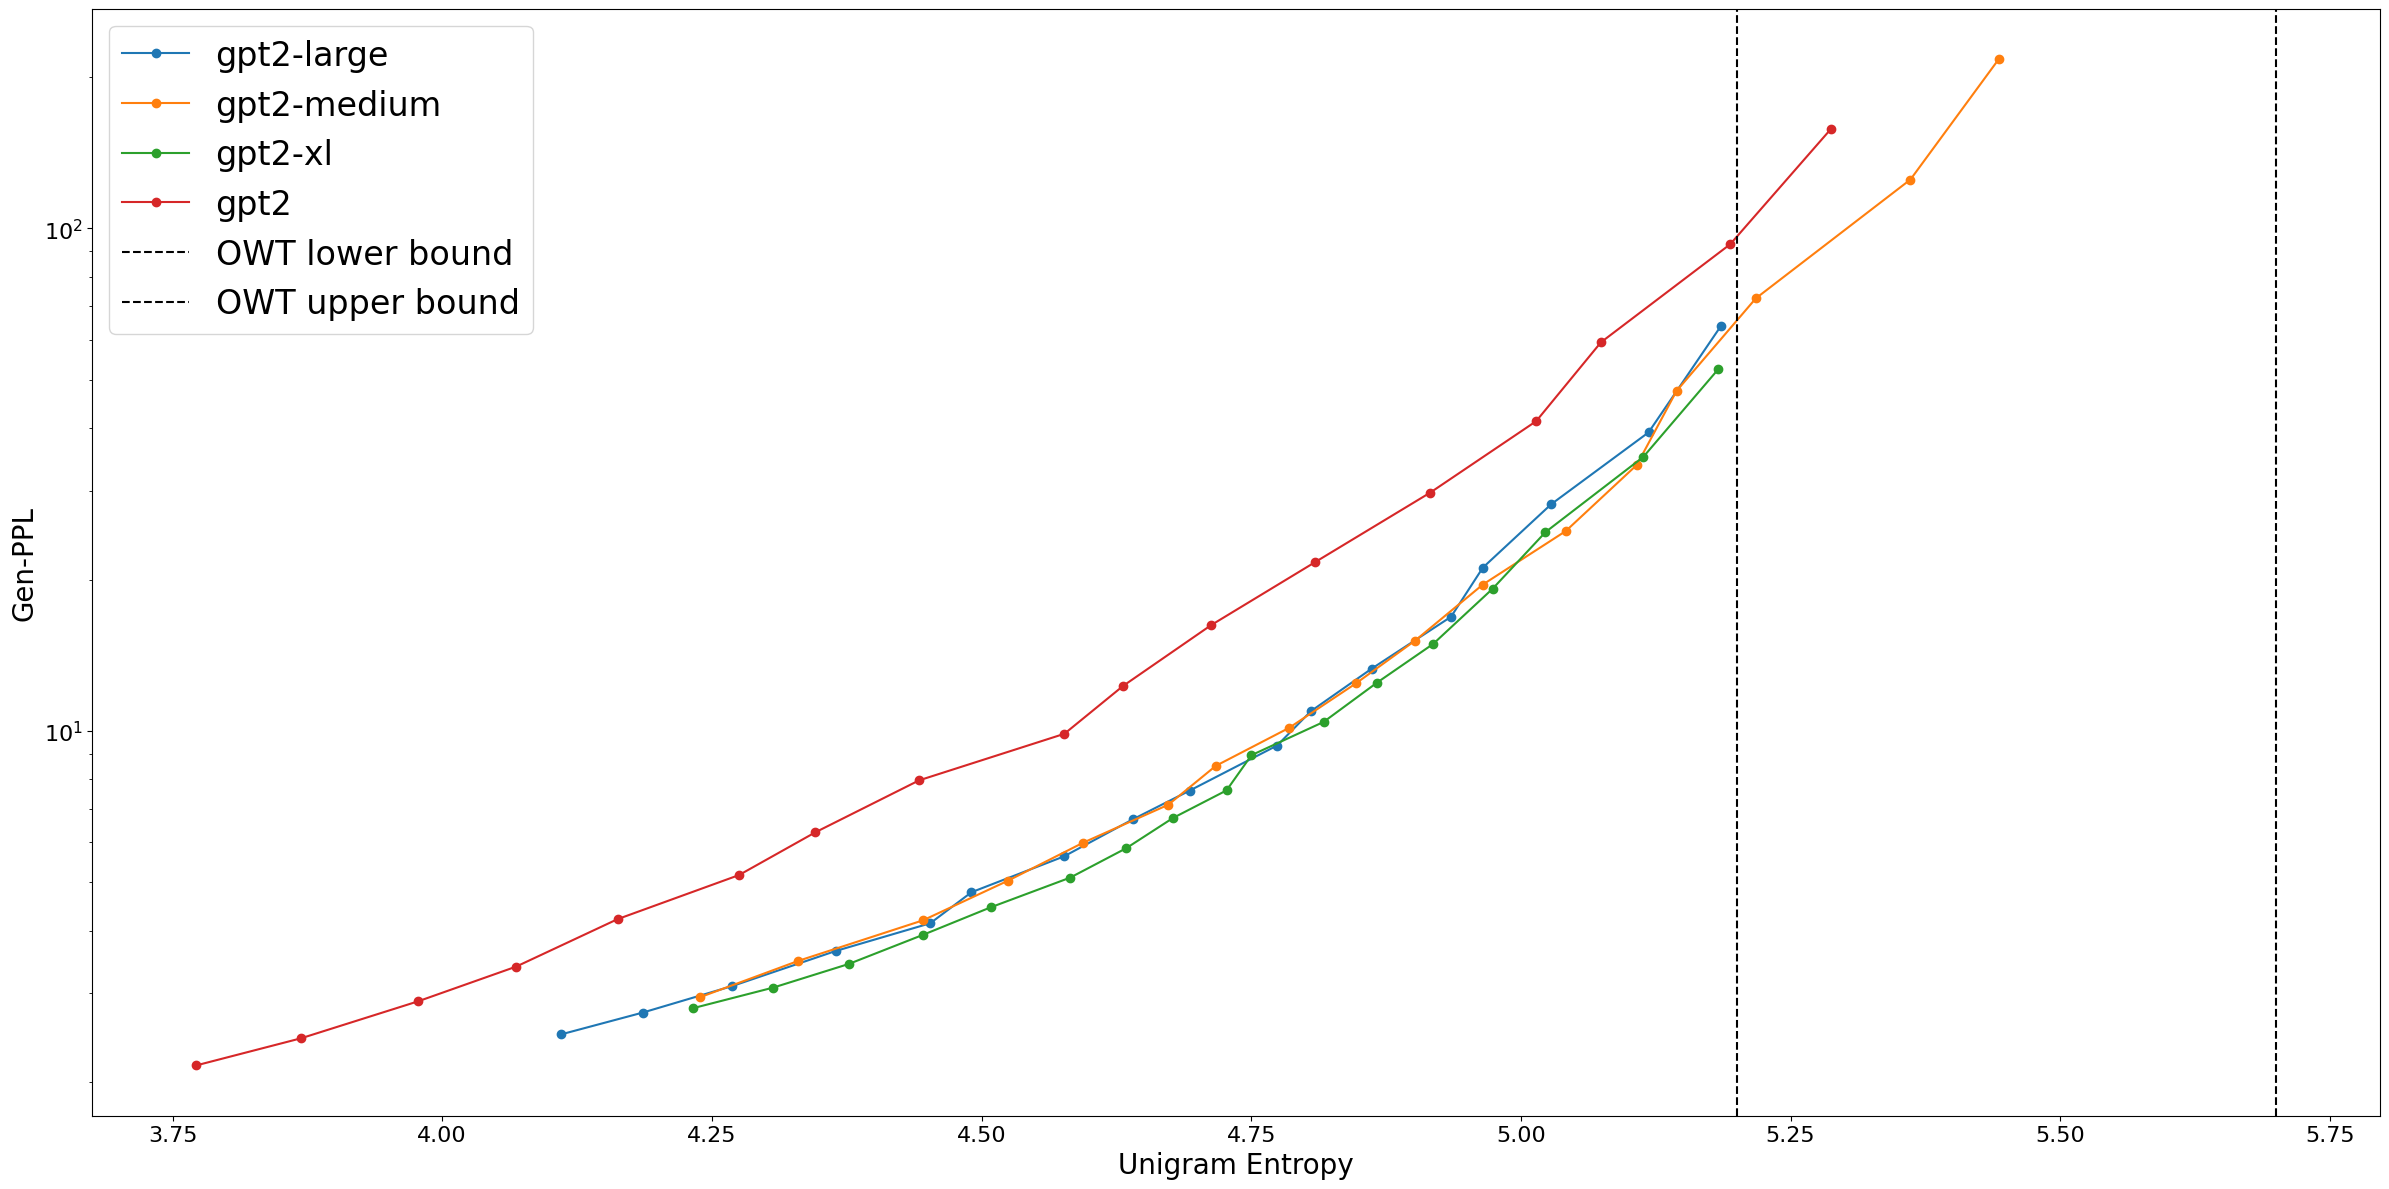

In [4]:
fig, ax = plt.subplots(figsize=(24, 12))
auc_results = {}

for model_idx in range(len(model_names)):

    model_name = model_names[model_idx]
    model_label = model_name.split('openai-community_')[1]
    df_model = df[df['method'] == model_name].sort_values('unigram_entropy')
    
    line, = ax.semilogy(df_model['unigram_entropy'], df_model['gen_ppl'], 
                         marker='o', markersize=6, label=model_label)
    
    """for x, y, temp in zip(df_model['unigram_entropy'], df_model['gen_ppl'], df_model['temperature']):
        ax.annotate(f'{temp:.2f}', xy=(x, y), xytext=(0, 8), 
                     textcoords='offset points', fontsize=10, 
                     color=line.get_color(), ha='center')"""
    
    auc = np.trapezoid(y=np.log(df_model['gen_ppl']), x=df_model['unigram_entropy'])
    auc_results[model_label] = auc

ax.axvline(x=5.2, color='black', linestyle='--', linewidth=1.5, label='OWT lower bound')
ax.axvline(x=5.7, color='black', linestyle='--', linewidth=1.5, label='OWT upper bound')
ax.set_xlabel('Unigram Entropy', fontsize=20)
ax.set_ylabel('Gen-PPL', fontsize=20)
ax.tick_params(axis='both', labelsize=16)
ax.legend(fontsize=24)
fig.tight_layout()
fig.show()



In [5]:
auc_results

{'gpt2-large': np.float64(2.2669703753680066),
 'gpt2-medium': np.float64(3.327898952736277),
 'gpt2-xl': np.float64(2.054450202846588),
 'gpt2': np.float64(3.716780406753606)}

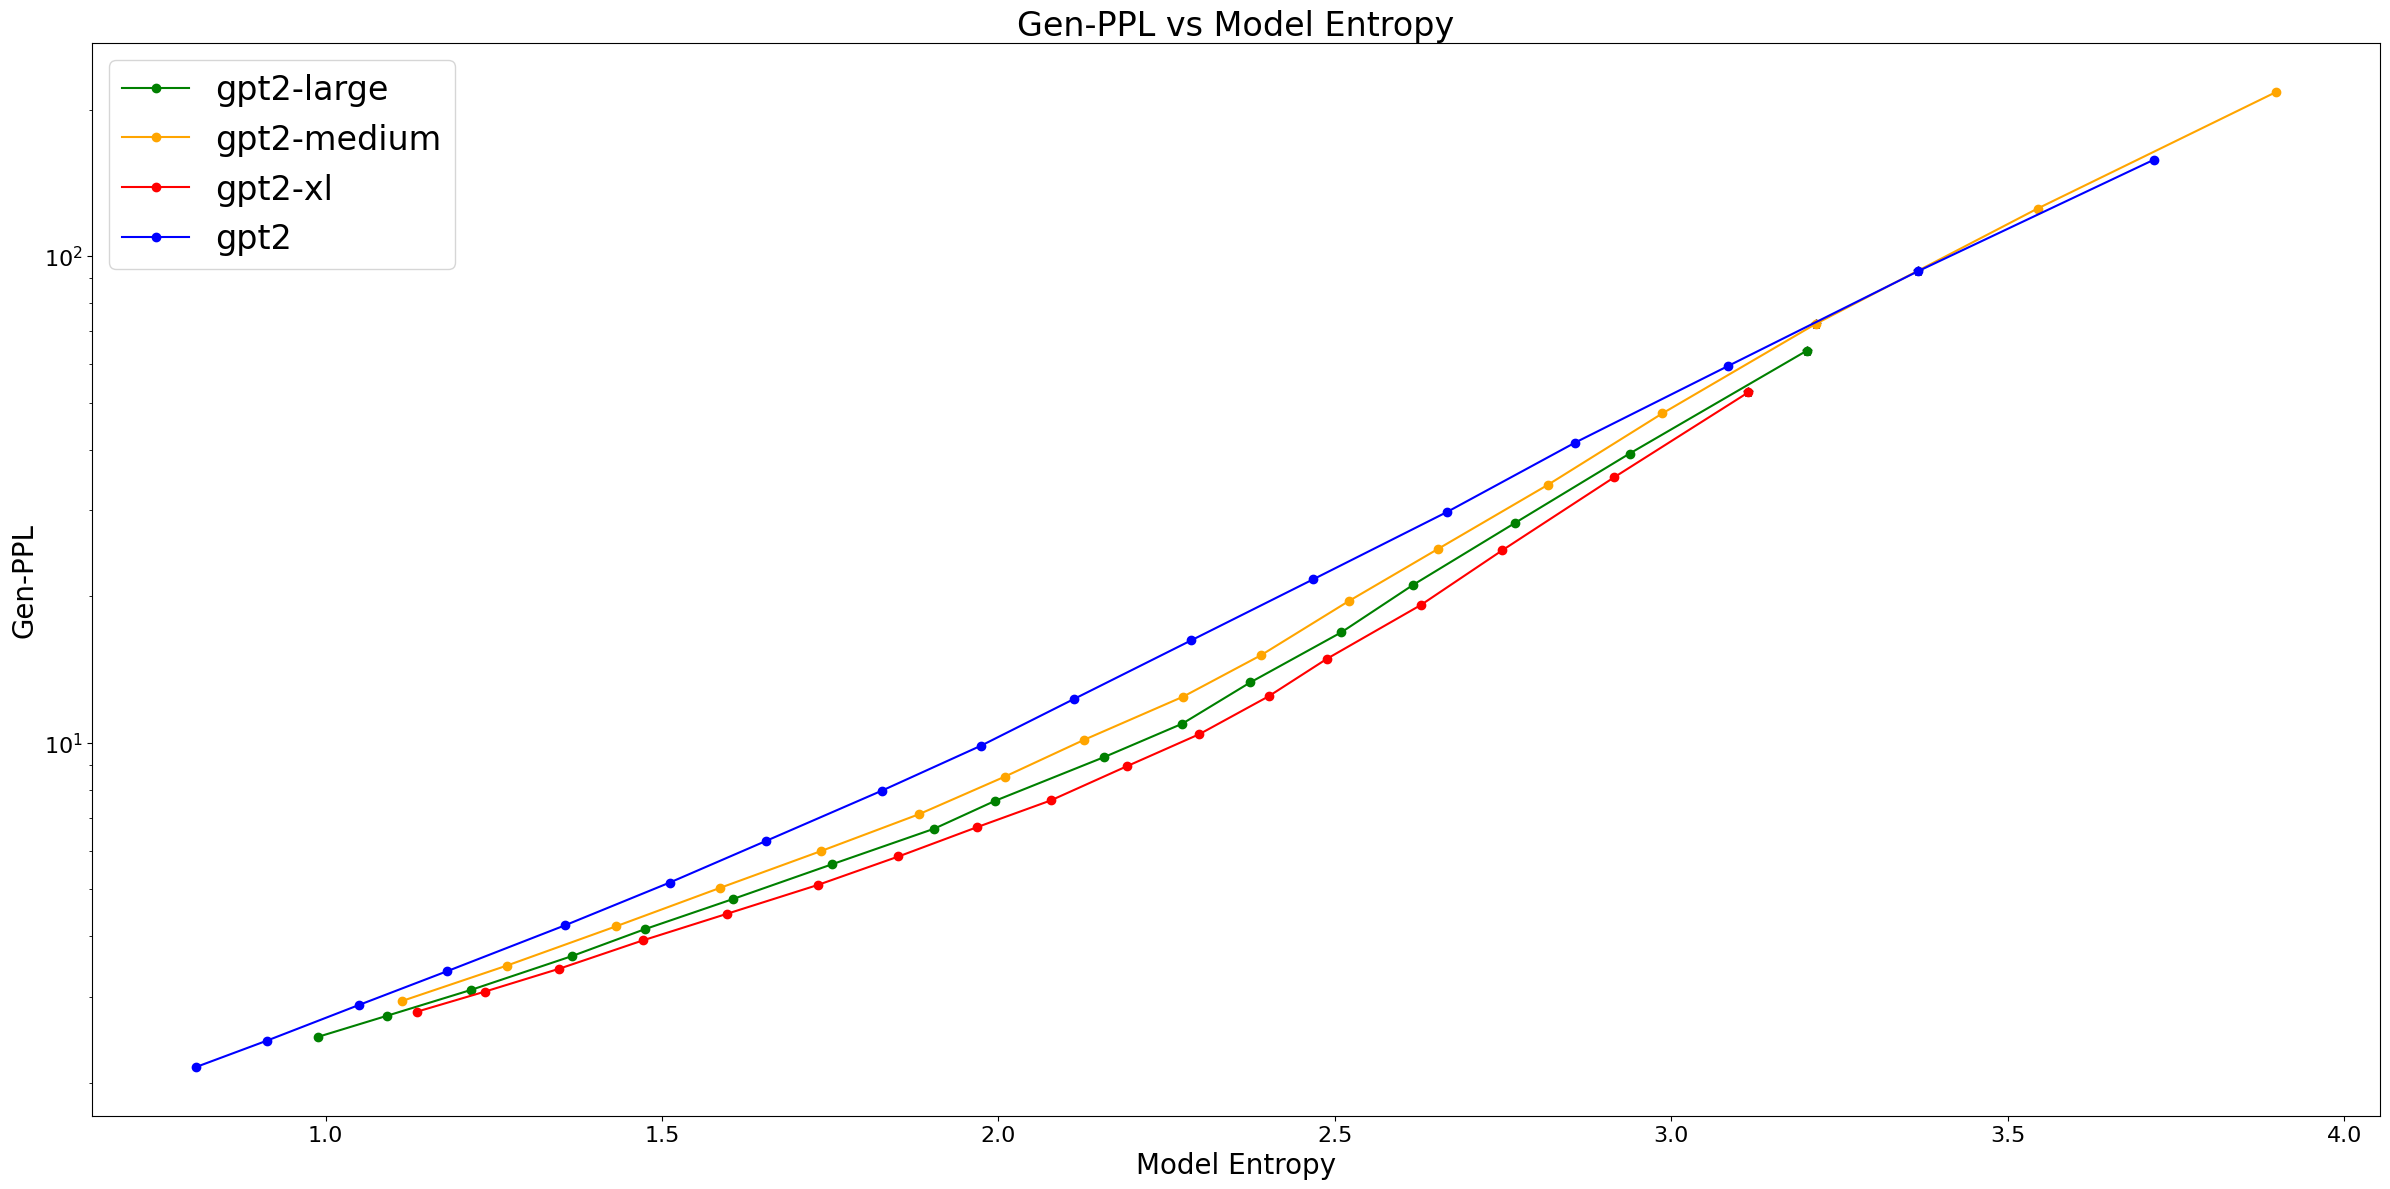

In [9]:
fig, ax = plt.subplots(figsize=(24, 12))
auc_results = {}

model_color_map = {
    "gpt2" : "blue",
    "gpt2-medium" : "orange",
    "gpt2-large" : "green",
    "gpt2-xl" : "red",
}

optimal_temp_map = {
    "gpt2": 0.975,
    "gpt2-medium": 0.95,
    "gpt2-large": 1.0,
    "gpt2-xl": 1.0,
}

for model_idx in range(len(model_names)):

    model_name = model_names[model_idx]
    model_label = model_name.split('openai-community_')[1]
    df_model = df[df['method'] == model_name].sort_values('model_entropy')
    color = model_color_map.get(model_label)

    line, = ax.semilogy(df_model['model_entropy'], df_model['gen_ppl'], marker='o', markersize=6, label=model_label, color=color)

    auc = np.trapezoid(y=np.log(df_model['gen_ppl']), x=df_model['model_entropy'])
    auc_results[model_label] = auc

    target_temp = optimal_temp_map[model_label]
    optimal_row = df_model[np.isclose(df_model['temperature'], target_temp)]
    ax.scatter(optimal_row['model_entropy'], optimal_row['gen_ppl'], marker='*',color=color,edgecolor='black',linewidth=1.5)

ax.set_xlabel('Model Entropy', fontsize=20)
ax.set_ylabel('Gen-PPL', fontsize=20)
ax.tick_params(axis='both', labelsize=16)
ax.set_title("Gen-PPL vs Model Entropy", fontsize=24)
ax.legend(fontsize=24)
fig.tight_layout()
fig.show()

In [7]:
auc_results

{'gpt2-large': np.float64(5.110675689479068),
 'gpt2-medium': np.float64(8.546188467853717),
 'gpt2-xl': np.float64(4.461692491945597),
 'gpt2': np.float64(8.18350661416469)}

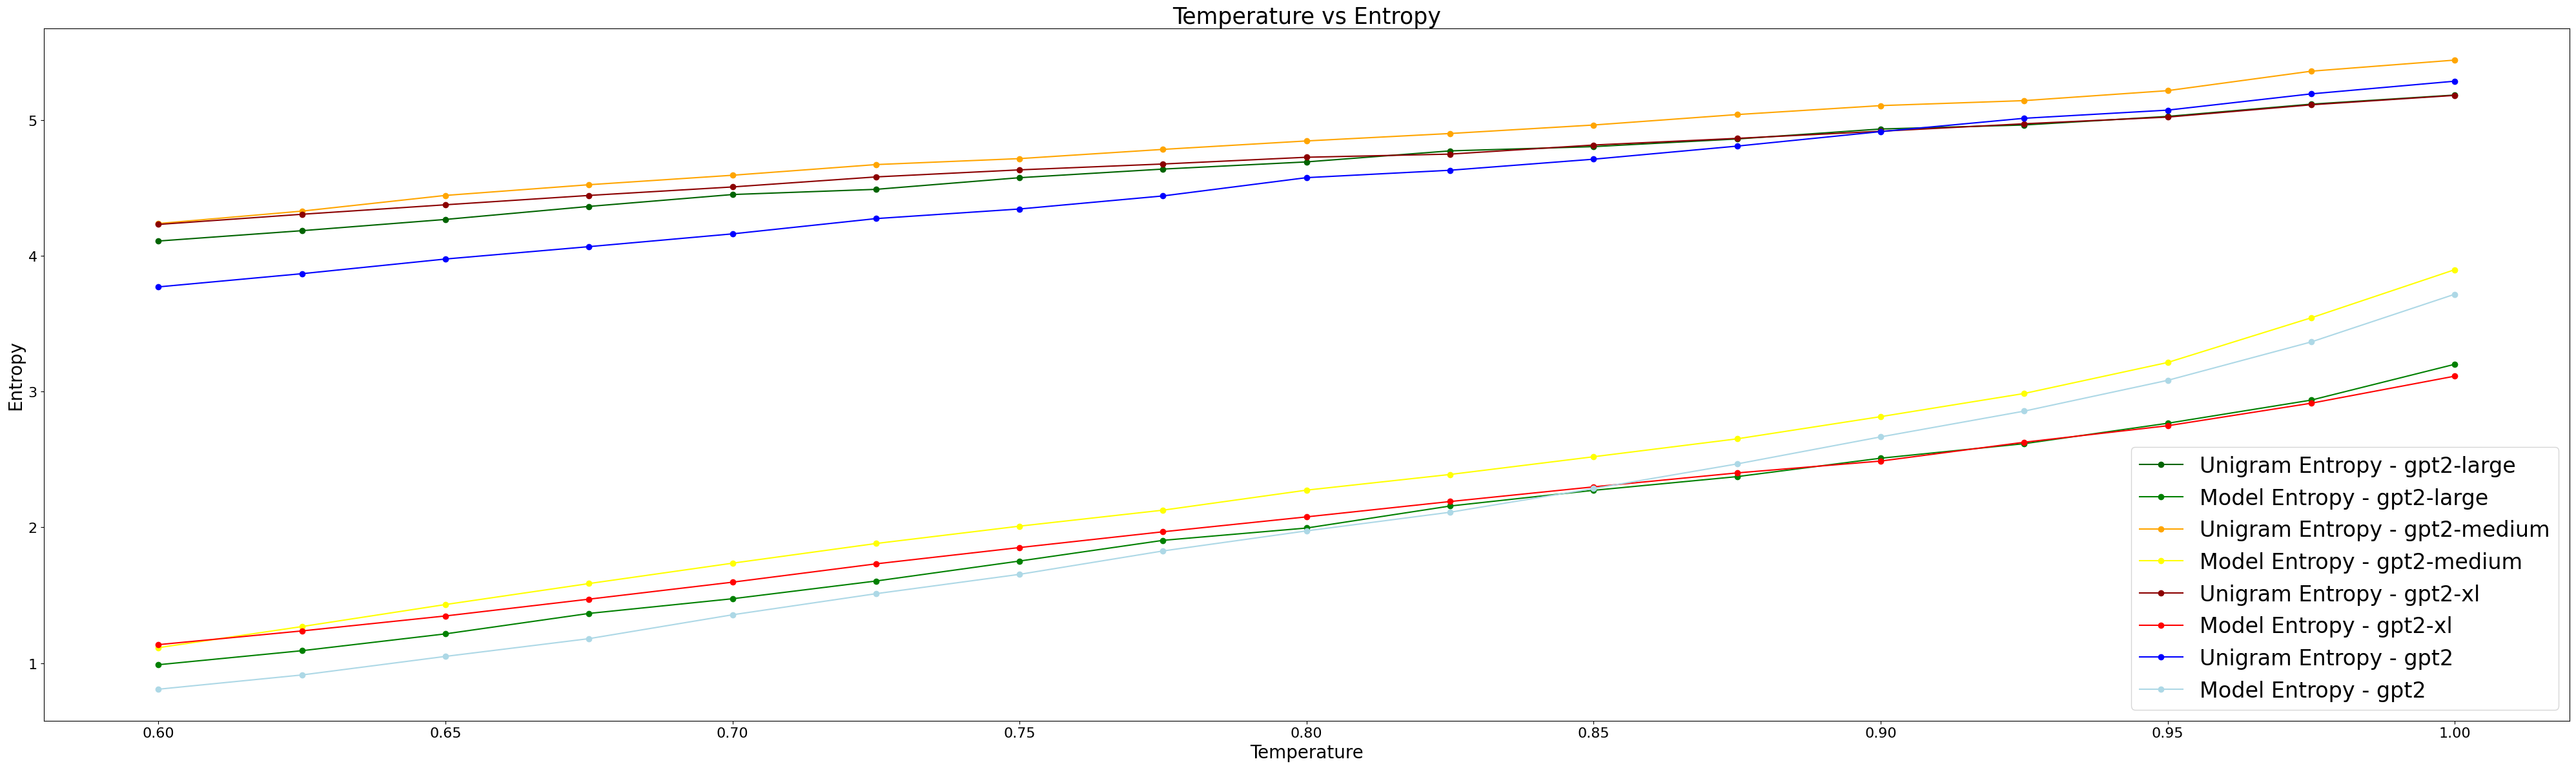

In [8]:
fig, ax = plt.subplots(figsize=(40, 12))
auc_results = {}

model_color_map = {
    "gpt2" : ["blue", "lightblue"],
    "gpt2-medium" : ["orange", "yellow"],
    "gpt2-large" : ["darkgreen", "green"],
    "gpt2-xl" : ["darkred", "red"],
}

for model_idx in range(len(model_names)):

    model_name = model_names[model_idx]
    model_label = model_name.split('openai-community_')[1]
    df_model = df[df['method'] == model_name]

    color = model_color_map.get(model_label)
    ax.plot(df_model['temperature'], df_model['unigram_entropy'], marker='o', markersize=6, label=f"Unigram Entropy - {model_label}", color=color[0])
    ax.plot(df_model['temperature'], df_model['model_entropy'], marker='o', markersize=6, label=f"Model Entropy - {model_label}", color=color[1])


ax.set_xlabel('Temperature', fontsize=20)
ax.set_ylabel('Entropy', fontsize=20)
ax.set_title("Temperature vs Entropy", fontsize=25)
ax.tick_params(axis='both', labelsize=16)
ax.legend(fontsize=24)

fig.tight_layout()
fig.show()